# Benchmark Results Explorer (Trend View)

이 노트북은 `reports/` 아래에 쌓이는 여러 벤치마크 결과(JSON)를 `data/benchmark_metrics.db`로 적재한 뒤,
**실행 순서(iteration / run 순번)** 기준으로 점수 변화만 빠르게 확인하기 위한 대시보드입니다.

## 이 노트북의 목적
- 세부 리포트(JSON)를 하나씩 열어보지 않고도 전체 추세를 확인
- 실험/수정 이후 점수가 개선되는지 빠르게 체크
- RL/코히런스/품질/비교 벤치마크를 같은 기준(시간순 run)으로 나란히 확인

## 데이터 흐름
1. `reports/*.json`에 각종 벤치마크 결과가 저장됨
2. `tools/benchmark_metrics_db.py ingest-all`이 JSON을 읽어 SQLite DB에 정규화 적재
3. 이 노트북이 DB를 조회해서 trend plot으로 표시

## 이 노트북에서 보는 축(axis)
- 대부분의 그래프 x축 `iter`는 **에피소드 turn이 아니라, 벤치마크 실행(run) 순서**입니다.
- 즉 `iter=1,2,3...` 는 "몇 번째 벤치마크 실행 결과인가"를 뜻합니다.

## 사용 메모
- 원본 JSON 리포트는 `reports/`에 그대로 유지됩니다.
- 이 노트북은 집계/조회용 DB(`data/benchmark_metrics.db`)만 사용합니다.
- RL 실행 중에도 `ingest-all --skip-errors`로 재적재 가능하도록 구성되어 있습니다.


In [134]:
from pathlib import Path
import sqlite3
import subprocess

import pandas as pd
import matplotlib.pyplot as plt


In [135]:

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None


def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'reports').exists() and (p / 'tools').exists():
            return p
    raise RuntimeError('Repo root not found')

REPO_ROOT = find_repo_root(Path.cwd())
DB_PATH = REPO_ROOT / 'data' / 'benchmark_metrics.db'
INGEST_SCRIPT = REPO_ROOT / 'tools' / 'benchmark_metrics_db.py'
REPO_ROOT, DB_PATH


(PosixPath('/Users/saesunkim/Documents/Novel Writter - 2026'),
 PosixPath('/Users/saesunkim/Documents/Novel Writter - 2026/data/benchmark_metrics.db'))

In [136]:
# Refresh DB from all report JSONs (safe to rerun while RL is running)
cmd = ['python3', str(INGEST_SCRIPT), '--db', str(DB_PATH), 'ingest-all', '--skip-errors']
print('Running:', ' '.join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)


Running: python3 /Users/saesunkim/Documents/Novel Writter - 2026/tools/benchmark_metrics_db.py --db /Users/saesunkim/Documents/Novel Writter - 2026/data/benchmark_metrics.db ingest-all --skip-errors
Ingest-all complete | ok=4 skipped=0 errors=0 | db=/Users/saesunkim/Documents/Novel Writter - 2026/data/benchmark_metrics.db


CompletedProcess(args=['python3', '/Users/saesunkim/Documents/Novel Writter - 2026/tools/benchmark_metrics_db.py', '--db', '/Users/saesunkim/Documents/Novel Writter - 2026/data/benchmark_metrics.db', 'ingest-all', '--skip-errors'], returncode=0)

In [137]:
con = sqlite3.connect(DB_PATH)

def q(sql: str, params=None) -> pd.DataFrame:
    return pd.read_sql_query(sql, con, params=params or {})

def _compact_label(v: str, max_len: int = 34) -> str:
    s = str(v)
    return s if len(s) <= max_len else s[:max_len - 1] + '…'

def _plot_trend(df: pd.DataFrame, x: str, y_cols: list[str], title: str, ylabel: str = 'score', ylim=(0, 1.05)):
    if df.empty:
        print('No data for', title)
        return
    ax = df.plot(x=x, y=y_cols, marker='o', figsize=(11, 4))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(ylabel)
    ax.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()


## Run Counts (sanity check)

가장 먼저 **데이터가 실제로 DB에 적재되었는지** 확인하는 섹션입니다.

확인 포인트:
- `report_type`별 파일 수가 0이 아닌지
- `latest_file_mtime_utc`가 최근 시간으로 갱신되는지

이 값이 기대와 다르면, 보통 원인은 아래 중 하나입니다.
- 벤치마크 JSON이 아직 `reports/`에 생성되지 않음
- `ingest-all` 셀이 실행되지 않았거나 실패함
- 노트북이 다른 DB 파일을 보고 있음 (경로/환경 문제)


In [138]:
report_counts = q('''
SELECT report_type, COUNT(*) AS files, MAX(file_mtime_utc) AS latest_file_mtime_utc
FROM report_files
GROUP BY report_type
ORDER BY report_type
''')
report_counts


,report_type,files,latest_file_mtime_utc
0,character_coherence,2,2026-02-26T17:43:05.593778+00:00
1,quality,2,2026-02-26T17:43:05.415327+00:00


## Coherence Score Trend (run iteration)

이 섹션은 **스토리/시리즈의 일관성(coherence)** 관련 점수의 run별 추이를 봅니다.

## 주요 점수 설명
- `series_coherence_score`
  - 에피소드 전이(예: ep01→ep02→ep03...) 중심으로 계산된 일관성 점수
  - 캐릭터/관계/감정/단서 회수 같은 전이 신호들이 포함될 수 있음

- `full_text_coherence_score`
  - 여러 에피소드 텍스트를 하나의 큰 코퍼스로 봤을 때의 전체 일관성 점수
  - 개별 전이보다 "전체적으로 같은 세계/같은 인물처럼 읽히는가"에 가까운 신호

- `series_coherence_score_with_full_text`
  - 전이 기반 점수 + full-text 기반 점수를 함께 반영한 종합 점수
  - 보통 이 값을 최종 비교 지표로 보기 쉽습니다.

- `global_character_voice_score`
  - 캐릭터 말투/보이스(voice) 일관성에 대한 신호
  - 대사 스타일/캐릭터별 표현 습관이 흔들리는지 보는 보조 지표

## 해석 팁
- `series`는 오르는데 `full_text`가 정체라면:
  - 에피소드 간 연결은 좋아졌지만, 전체 텍스트 톤/캐릭터성은 아직 불안정할 수 있음
- `full_text`는 좋은데 `series`가 낮다면:
  - 문체는 안정적이지만 사건/관계 전이가 어색할 수 있음
- `voice`가 급락하면:
  - 특정 수정으로 캐릭터 말투가 무너졌는지 의심해볼 만함

## 주의점
- 서로 다른 에피소드 범위(ep01~05 vs ep01~10)의 run이 섞이면 절대 비교보다 **추세 비교** 중심으로 보는 것이 안전합니다.


In [139]:
coh_trend = q('''
SELECT
  ROW_NUMBER() OVER (ORDER BY r.file_mtime_utc, c.id) AS iter,
  r.label,
  r.file_mtime_utc,
  c.ep_start,
  c.ep_end,
  c.episode_count,
  c.series_coherence_score,
  c.full_text_coherence_score,
  c.series_coherence_score_with_full_text,
  c.protagonist_presence_rate,
  c.global_character_voice_score
FROM coherence_runs c
JOIN report_files r ON r.id = c.report_file_id
ORDER BY r.file_mtime_utc, c.id
''')
if not coh_trend.empty:
    coh_trend['label_short'] = coh_trend['label'].map(_compact_label)
coh_trend[['iter', 'label_short', 'file_mtime_utc', 'series_coherence_score', 'full_text_coherence_score', 'series_coherence_score_with_full_text']]


,iter,label_short,file_mtime_utc,series_coherence_score,full_text_coherence_score,series_coherence_score_with_full_text
0,1,character_coherence_ep01_ep10_gen…,2026-02-26T17:43:02.619455+00:00,0.756,1.000,0.817
1,2,character_coherence_ep01_ep10_goo…,2026-02-26T17:43:05.593778+00:00,0.522,0.692,0.565


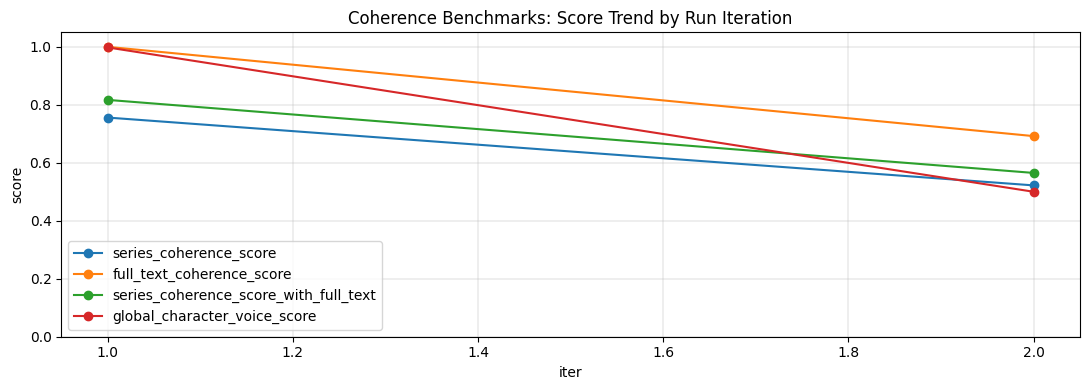

In [140]:
_plot_trend(
    coh_trend,
    x='iter',
    y_cols=['series_coherence_score', 'full_text_coherence_score', 'series_coherence_score_with_full_text', 'global_character_voice_score'],
    title='Coherence Benchmarks: Score Trend by Run Iteration'
)


## Quality Score Trend (run iteration)

이 섹션은 **품질 평가(quality benchmark)** 결과를 run 단위 평균 점수로 단순화해서 보여줍니다.

## 무엇을 보여주나?
- `avg_overall_score`
  - 해당 quality run에 포함된 에피소드들의 `overall_score` 평균값
  - 세부 metric들을 한 번에 요약해 보는 상위 지표

## 왜 평균만 보나?
- 에피소드별 세부 점수까지 동시에 보면 정보량이 너무 커져서,
  먼저 run 수준에서 "좋아지는지 / 나빠지는지"를 확인하기 어렵습니다.
- 이 노트북은 추세 확인용이므로 평균 점수 중심으로 단순화했습니다.

## 해석 팁
- 완만한 상승: 지속적 개선 가능성
- 급락: 최근 프롬프트/정책/생성 로직 변경 영향 가능성
- 점수는 오르는데 체감 품질이 안 좋아 보이면:
  - 평가 rubric과 실제 목표가 어긋났는지 점검 필요

## 보조 컬럼
- `total_episodes`: 해당 run 평가에 포함된 에피소드 수
- `passed`: run 단위 pass 여부(리포트 생성 로직 기준)


In [141]:
quality_trend = q('''
SELECT
  ROW_NUMBER() OVER (ORDER BY r.file_mtime_utc, qrun.id) AS iter,
  r.label,
  r.file_mtime_utc,
  qrun.ep_start,
  qrun.ep_end,
  qrun.total_episodes,
  qrun.avg_overall_score,
  qrun.passed
FROM quality_runs qrun
JOIN report_files r ON r.id = qrun.report_file_id
ORDER BY r.file_mtime_utc, qrun.id
''')
if not quality_trend.empty:
    quality_trend['label_short'] = quality_trend['label'].map(_compact_label)
quality_trend[['iter', 'label_short', 'file_mtime_utc', 'avg_overall_score', 'total_episodes', 'passed']]


,iter,label_short,file_mtime_utc,avg_overall_score,total_episodes,passed
0,1,quality_ep01_ep10_generated_20260…,2026-02-26T17:43:03.258742+00:00,0.8990,10,10
1,2,quality_ep01_ep10_good_example_20…,2026-02-26T17:43:05.415327+00:00,0.8249,10,10


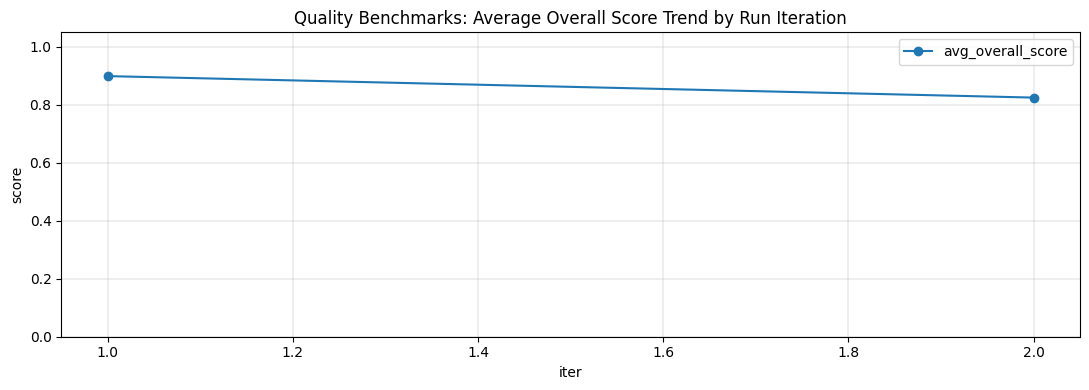

In [142]:
_plot_trend(
    quality_trend,
    x='iter',
    y_cols=['avg_overall_score'],
    title='Quality Benchmarks: Average Overall Score Trend by Run Iteration'
)


## Comparison Benchmark Trend (run iteration)

이 섹션은 legacy/iter 스타일 비교 벤치마크를 **단일 비율 지표**로 추세화해서 보여줍니다.

## 핵심 지표
- `output_closer_ratio = output_closer_count / total`

의미:
- 비교 대상(예: baseline vs good example) 중에서,
  현재 출력이 얼마나 자주 "좋은 쪽"에 더 가깝다고 판정되었는지를 비율로 표현한 값입니다.
- 값이 높을수록 비교 기준에서 더 좋은 방향으로 움직였다고 해석할 수 있습니다.

## 왜 metric별로 나눠서 그리나?
- comparison benchmark는 `metric` 종류가 여러 개일 수 있음
- 서로 스케일/의미가 다를 수 있으므로 같은 plot에 섞기보다 metric별 추세를 따로 보는 편이 안전함

## 해석 팁
- 특정 metric만 개선되고 다른 metric은 정체/악화되면:
  - 개선이 편향되었을 수 있음 (한 측면만 좋아짐)
- `total`이 매우 작은 run은 비율 변동폭이 커질 수 있으니 과해석 주의


In [143]:
cmp_trend = q('''
SELECT
  ROW_NUMBER() OVER (ORDER BY rf.file_mtime_utc, cr.id) AS iter,
  rf.label,
  rf.file_mtime_utc,
  cr.metric,
  cr.total,
  cr.output_closer_count,
  CASE WHEN cr.total > 0 THEN 1.0 * cr.output_closer_count / cr.total END AS output_closer_ratio
FROM comparison_runs cr
JOIN report_files rf ON rf.id = cr.report_file_id
ORDER BY rf.file_mtime_utc, cr.id
''')
if not cmp_trend.empty:
    cmp_trend['label_short'] = cmp_trend['label'].map(_compact_label)
cmp_trend[['iter', 'label_short', 'metric', 'output_closer_ratio', 'total', 'output_closer_count']]


KeyError: "['label_short'] not in index"

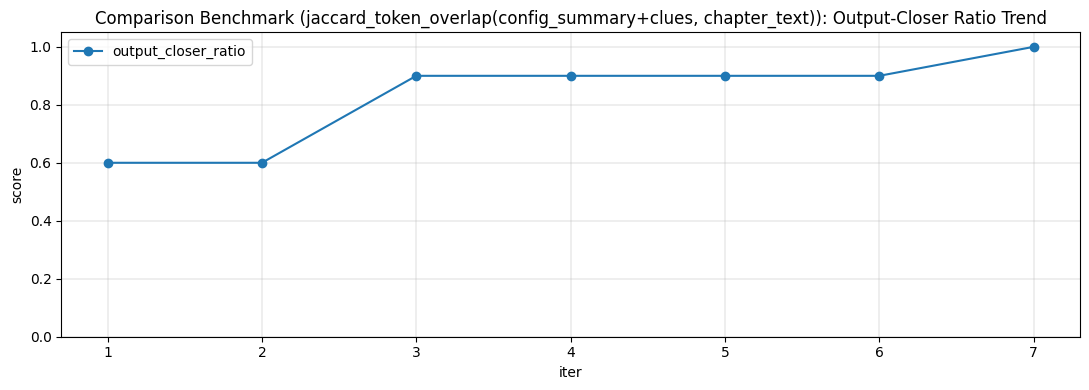

In [ ]:
if not cmp_trend.empty:
    for metric, g in cmp_trend.groupby('metric'):
        _plot_trend(
            g.sort_values('iter'),
            x='iter',
            y_cols=['output_closer_ratio'],
            title=f'Comparison Benchmark ({metric}): Output-Closer Ratio Trend'
        )


## RL Score Trend

이 섹션은 RL 관련 결과를 **두 레벨**로 나눠서 보여줍니다.

## 1) RL Runs (run iteration 기준)
- x축 `iter`: RL 실행(run) 자체의 순서
- y축 `best_reward`: 각 RL run에서 얻은 최고 보상

이 그래프는 다음 질문에 답합니다.
- "최근 RL 실험이 이전 RL 실험보다 좋아졌나?"
- "정책 탐색/보상 설계 변경이 run 전체 성과를 개선했나?"

## 2) RL Iteration Trend (최신 run 내부 round 기준)
- x축 `round`: 최신 RL run 안의 iteration/round
- y축 `reward`, `best_reward`

이 그래프는 다음 질문에 답합니다.
- "최신 RL 실행 내부에서 학습이 진행되며 보상이 올라가고 있나?"
- "탐색(explore) 때문에 일시적으로 떨어져도 best는 유지/개선되나?"

## 해석 팁
- `reward`는 흔들려도 `best_reward`가 계단식으로 상승하면 정상적인 탐색/개선 패턴일 수 있음
- `reward`와 `best_reward`가 둘 다 평평하면:
  - 탐색 폭 부족, 보상 설계 문제, 정책 변경 폭 제한 등을 의심
- run 간 `best_reward`가 계속 낮아지면:
  - 최근 코드/환경/평가 기준 변경 여부 확인 필요


In [ ]:
rl_run_trend = q('''
SELECT
  ROW_NUMBER() OVER (ORDER BY rf.file_mtime_utc, rr.id) AS iter,
  rr.id AS rl_run_id,
  rf.label,
  rf.file_mtime_utc,
  rr.rounds,
  rr.best_reward
FROM rl_runs rr
JOIN report_files rf ON rf.id = rr.report_file_id
ORDER BY rf.file_mtime_utc, rr.id
''')
if not rl_run_trend.empty:
    rl_run_trend['label_short'] = rl_run_trend['label'].map(_compact_label)
rl_run_trend[['iter', 'label_short', 'file_mtime_utc', 'rounds', 'best_reward']]


,iter,label_short,file_mtime_utc,rounds,best_reward
0,1,rl_code_policy_history_ep01_ep05,2026-02-24T14:21:05.017109+00:00,3,0.841
1,2,rl_code_policy_history_ep01_ep05_…,2026-02-24T16:44:59.891456+00:00,10,0.841


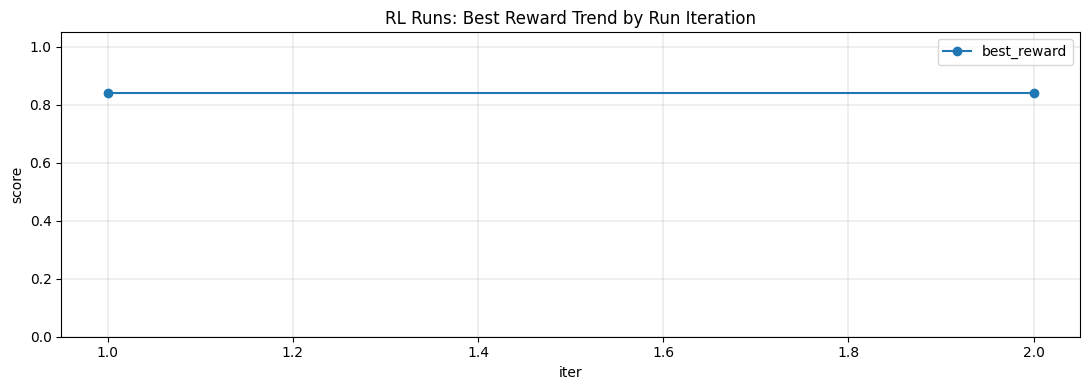

In [ ]:
_plot_trend(
    rl_run_trend,
    x='iter',
    y_cols=['best_reward'],
    title='RL Runs: Best Reward Trend by Run Iteration'
)


In [ ]:
rl_iter = q('''
SELECT
  rr.id AS rl_run_id,
  rf.label,
  rf.file_mtime_utc,
  ri.round,
  ri.reward,
  ri.best_reward,
  ri.accepted,
  ri.explore
FROM rl_iterations ri
JOIN rl_runs rr ON rr.id = ri.rl_run_id
JOIN report_files rf ON rf.id = rr.report_file_id
ORDER BY rf.file_mtime_utc, rr.id, ri.round
''')

if rl_iter.empty:
    print('No RL iteration rows found.')
else:
    latest_rl_run_id = int(rl_iter['rl_run_id'].iloc[-1])
    latest_label = rl_iter.loc[rl_iter['rl_run_id'] == latest_rl_run_id, 'label'].iloc[0]
    latest = rl_iter[rl_iter['rl_run_id'] == latest_rl_run_id].sort_values('round').copy()
    print('Latest RL run:', latest_label)
    latest[['round', 'reward', 'best_reward', 'accepted', 'explore']]


Latest RL run: rl_code_policy_history_ep01_ep05_round10


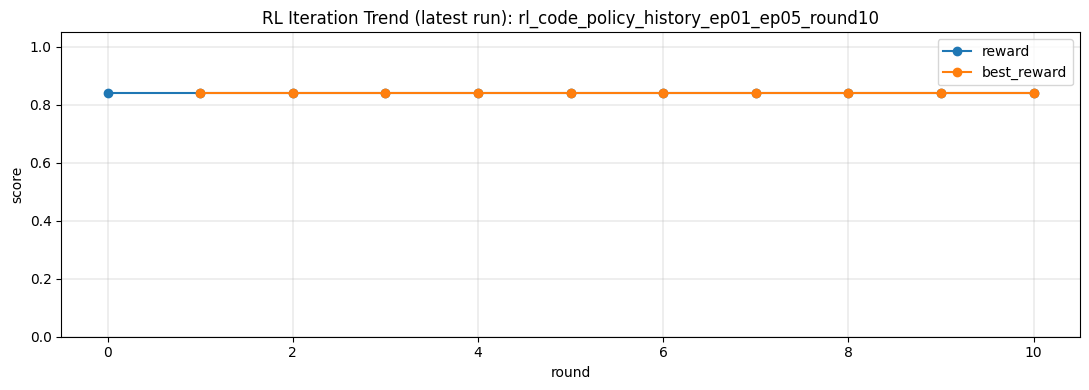

In [ ]:
if not rl_iter.empty:
    latest_rl_run_id = int(rl_iter['rl_run_id'].iloc[-1])
    latest_label = rl_iter.loc[rl_iter['rl_run_id'] == latest_rl_run_id, 'label'].iloc[0]
    latest = rl_iter[rl_iter['rl_run_id'] == latest_rl_run_id].sort_values('round').copy()
    _plot_trend(
        latest,
        x='round',
        y_cols=['reward', 'best_reward'],
        title=f'RL Iteration Trend (latest run): {_compact_label(latest_label, 60)}'
    )


## Notes

현재 버전은 **점수 추이 확인**에 집중한 뷰입니다.

## 일부러 제외한 것들 (정보 과밀 방지)
- transition-level 상세 테이블
- episode-level 세부 metric 테이블
- RL 정책 파라미터별 상세 변화 그래프

## 이런 흐름으로 보는 것을 추천
1. `Run Counts`에서 데이터 적재 상태 확인
2. `Coherence` / `Quality` / `Comparison`에서 run 추세 확인
3. `RL`에서 run 간 성능 + 최신 run 내부 학습 패턴 확인
4. 이상 구간이 있으면 해당 JSON 리포트/원본 로그로 drill-down

## 다음 확장 아이디어
- 최근 N개 run만 보기 필터
- 벤치마크 태그/실험명별 그룹핑
- 동일 에피소드 범위끼리만 비교하는 필터
